Triển khai thuật toán phân cụm K-Means
Chúng ta sẽ sử dụng các tập dữ liệu blob và trình bày cách tạo cụm bằng ngôn ngữ lập trình Python .

Bước 1: Nhập các thư viện cần thiết
Chúng tôi sẽ nhập khẩu các thư viện sau.

Numpy : dùng cho các phép toán số học (ví dụ: tính khoảng cách).

Matplotlib : thư viện dùng để vẽ đồ thị dữ liệu và kết quả.

Scikit learn : tạo tập dữ liệu tổng hợp bằng cách sử dụng make_blobs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

Bước 2 : Tạo tập dữ liệu tùy chỉnh
Chúng ta sẽ tạo một tập dữ liệu tổng hợp bằng make_blobs.

make_blobs(n_samples=500, n_features=2, centers=3): Tạo ra 500 điểm dữ liệu trong không gian 2D, được nhóm thành 3 cụm.

plt.scatter(X[:, 0], X[:, 1]): Vẽ biểu đồ tập dữ liệu dưới dạng 2D, hiển thị tất cả các điểm.

plt.show(): Hiển thị biểu đồ

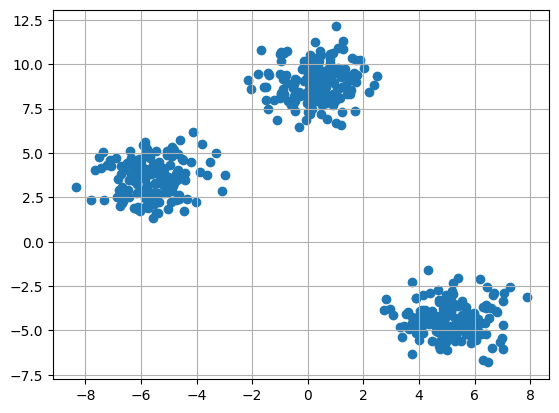

In [2]:
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 23)

fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.show()

Bước 3: Khởi tạo các tâm ngẫu nhiên
Chúng ta sẽ khởi tạo ngẫu nhiên các tâm cụm cho thuật toán phân cụm K-Means.

np.random.seed(23): Đảm bảo khả năng tái tạo bằng cách cố định hạt giống ngẫu nhiên.

Vòng lặp for khởi tạo k tâm ngẫu nhiên, với các giá trị nằm giữa -2 và 2, cho một tập dữ liệu 2D.

In [3]:
k = 3

clusters = {}
np.random.seed(23)

for idx in range(k):
    center = 2*(2*np.random.random((X.shape[1],))-1)
    points = []
    cluster = {
        'center' : center,
        'points' : []
    }
    
    clusters[idx] = cluster
    
clusters

{0: {'center': array([0.06919154, 1.78785042]), 'points': []},
 1: {'center': array([ 1.06183904, -0.87041662]), 'points': []},
 2: {'center': array([-1.11581855,  0.74488834]), 'points': []}}

Bước 4: Vẽ tâm được khởi tạo ngẫu nhiên với các điểm dữ liệu
Bây giờ chúng ta sẽ vẽ các điểm dữ liệu và các tâm ban đầu.

plt.grid() : Vẽ một lưới.

plt.scatter(center[0], center[1], marker='*', c='red'): Vẽ tâm cụm dưới dạng một ngôi sao màu đỏ (đánh dấu *).

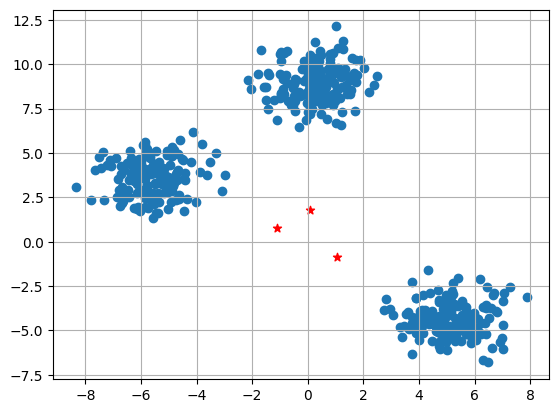

In [4]:
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '*',c = 'red')
plt.show()

Bước 5: Định nghĩa khoảng cách Euclidean
Để gán các điểm dữ liệu cho tâm gần nhất, chúng ta định nghĩa một hàm khoảng cách:

np.sqrt(): Tính căn bậc hai của một số hoặc từng phần tử trong mảng.

np.sum(): Tính tổng tất cả các phần tử trong một mảng hoặc dọc theo một trục được chỉ định.

In [5]:
def distance(p1,p2):
    return np.sqrt(np.sum((p1-p2)**2))

Bước 6: Tạo các hàm Gán và Cập nhật
Tiếp theo, chúng ta định nghĩa các hàm để gán điểm cho tâm cụm gần nhất và cập nhật các tâm cụm dựa trên giá trị trung bình của các điểm được gán cho mỗi cụm.

dist.append(dis): Thêm khoảng cách đã tính toán vào danh sách dist.

curr_cluster = np.argmin(dist): Tìm chỉ số của cụm gần nhất bằng cách chọn khoảng cách tối thiểu.

new_center = points.mean(axis=0): Tính toán tâm cụm mới bằng cách lấy trung bình cộng của các điểm trong cụm.

In [6]:
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]):
        dist = []
        
        curr_x = X[idx]
        
        for i in range(k):
            dis = distance(curr_x,clusters[i]['center'])
            dist.append(dis)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

def update_clusters(X, clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            new_center = points.mean(axis =0)
            clusters[i]['center'] = new_center
            
            clusters[i]['points'] = []
    return clusters

Bước 7: Dự đoán cụm cho các điểm dữ liệu
Chúng tôi tạo một hàm để dự đoán cụm cho mỗi điểm dữ liệu dựa trên các tâm cụm cuối cùng.

pred.append(np.argmin(dist)): Thêm chỉ số của cụm gần nhất (cụm có khoảng cách tối thiểu) vào pred.

In [7]:
def pred_cluster(X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

Bước 8: Phân bổ, cập nhật và dự đoán các trung tâm cụm
Chúng tôi gán điểm vào các cụm, cập nhật tâm cụm và dự đoán nhãn cụm cuối cùng.

assign_clusters(X, clusters): Gán các điểm dữ liệu cho các tâm cụm gần nhất.

update_clusters(X, clusters): Tính toán lại tâm cụm.

pred_cluster(X, clusters): Dự đoán các cụm cuối cùng cho tất cả các điểm dữ liệu.

clusters = assign_clusters(X,clusters)
clusters = update_clusters(X,clusters)
pred = pred_cluster(X,clusters)

Bước 9: Vẽ biểu đồ các điểm dữ liệu với các tâm cụm dự đoán
Cuối cùng, chúng ta vẽ các điểm dữ liệu, được tô màu theo các cụm dự đoán của chúng, cùng với các tâm cụm được cập nhật.

center = clusters[i]['center']: Truy xuất tâm (trọng tâm) của cụm hiện tại.

plt.scatter(center[0], center[1], marker='^', c='red'): Vẽ tâm cụm dưới dạng hình tam giác màu đỏ (^ marker).

In [8]:
plt.scatter(X[:,0],X[:,1],c = pred)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.show()

NameError: name 'pred' is not defined